Train data: (10000, 32, 32, 3)
Train label: (10000,)
Test data: (2000, 32, 32, 3)
Test label: (2000,)


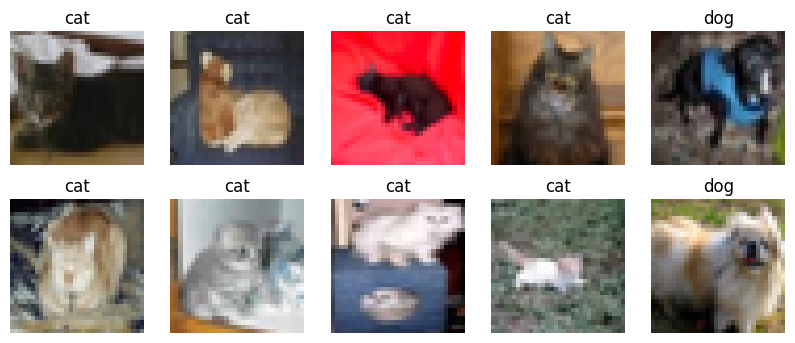

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# =========================
# 1. CIFAR-10 데이터 로드
# =========================

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 class index
# airplane: 0
# automobile: 1
# bird: 2
# cat: 3
# deer: 4
# dog: 5
# frog: 6
# horse: 7
# ship: 8
# truck: 9

CAT_LABEL = 3
DOG_LABEL = 5

# =========================
# 2. Cat / Dog 데이터만 선택
# =========================

train_mask = np.where((y_train[:, 0] == CAT_LABEL) | (y_train[:, 0] == DOG_LABEL))[0]
test_mask = np.where((y_test[:, 0] == CAT_LABEL) | (y_test[:, 0] == DOG_LABEL))[0]

x_train_cd = x_train[train_mask]
y_train_cd = y_train[train_mask]

x_test_cd = x_test[test_mask]
y_test_cd = y_test[test_mask]

# =========================
# 3. 라벨 변환
# cat -> 0
# dog -> 1
# =========================

y_train_cd = np.where(y_train_cd[:, 0] == CAT_LABEL, 0, 1)
y_test_cd = np.where(y_test_cd[:, 0] == CAT_LABEL, 0, 1)

# =========================
# 4. 정규화
# =========================

x_train_cd = x_train_cd.astype("float32") / 255.0
x_test_cd = x_test_cd.astype("float32") / 255.0

print("Train data:", x_train_cd.shape)
print("Train label:", y_train_cd.shape)
print("Test data:", x_test_cd.shape)
print("Test label:", y_test_cd.shape)

# =========================
# 5. 데이터 확인
# =========================

class_names = ["cat", "dog"]

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_cd[i])
    plt.title(class_names[y_train_cd[i]])
    plt.axis("off")
plt.show()

In [11]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *

In [12]:
model = Sequential()
model.add(Conv2D(64, activation='relu', kernel_size=(3,3 )))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(32, activation='relu', kernel_size=(3,3 )))
model.add(Flatten(input_shape = (32, 32, 3)))
model.add(Dense(80, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [13]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_cd, y_train_cd, epochs=10, verbose=1, validation_split=0.3)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.5651 - loss: 0.6805 - val_accuracy: 0.5293 - val_loss: 0.8543
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.6361 - loss: 0.6354 - val_accuracy: 0.6417 - val_loss: 0.6271
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.6789 - loss: 0.5962 - val_accuracy: 0.6690 - val_loss: 0.6038
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.7003 - loss: 0.5701 - val_accuracy: 0.6740 - val_loss: 0.6019
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.7367 - loss: 0.5291 - val_accuracy: 0.6937 - val_loss: 0.5910
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.7564 - loss: 0.4936 - val_accuracy: 0.7107 - val_loss: 0.5719
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.7864 - loss: 0.4471 - val_accuracy: 0.6833 - val_loss: 0.6297
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.8251 - loss: 0.3817 - 

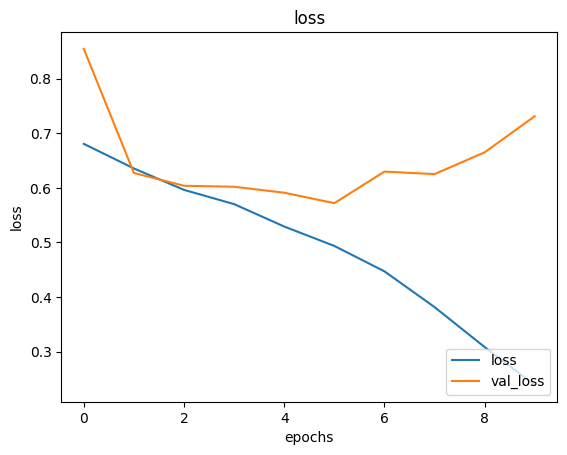

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['loss', 'val_loss'], loc='lower right')
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
정답= 0
예측값= [0.03771422]


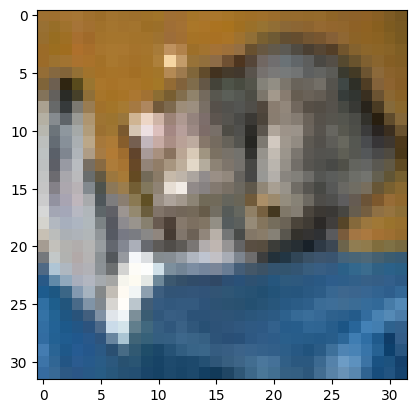

In [15]:
plt.figure()
plt.imshow(x_test_cd[0])
y_pred = model.predict(x_test_cd)
print("정답=", y_test_cd[0])
print("예측값=", y_pred[0])